In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [3]:
DATA_PATH = "../data/raw/airbnb.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(98970, 20)

In [4]:
cols = [
    "price",
    "reviews per month",
    "availability 365",
    "service fee",
    "minimum nights"
]

df_selected = df[cols].copy()

df_selected.head()

,price,reviews per month,availability 365,service fee,minimum nights
0,966.0,0.21,286.0,193.0,10.0
1,142.0,0.38,228.0,28.0,30.0
2,620.0,0.00,352.0,124.0,3.0
3,368.0,4.64,322.0,74.0,30.0
4,204.0,0.10,289.0,41.0,10.0


In [5]:
df_selected = df_selected.dropna()

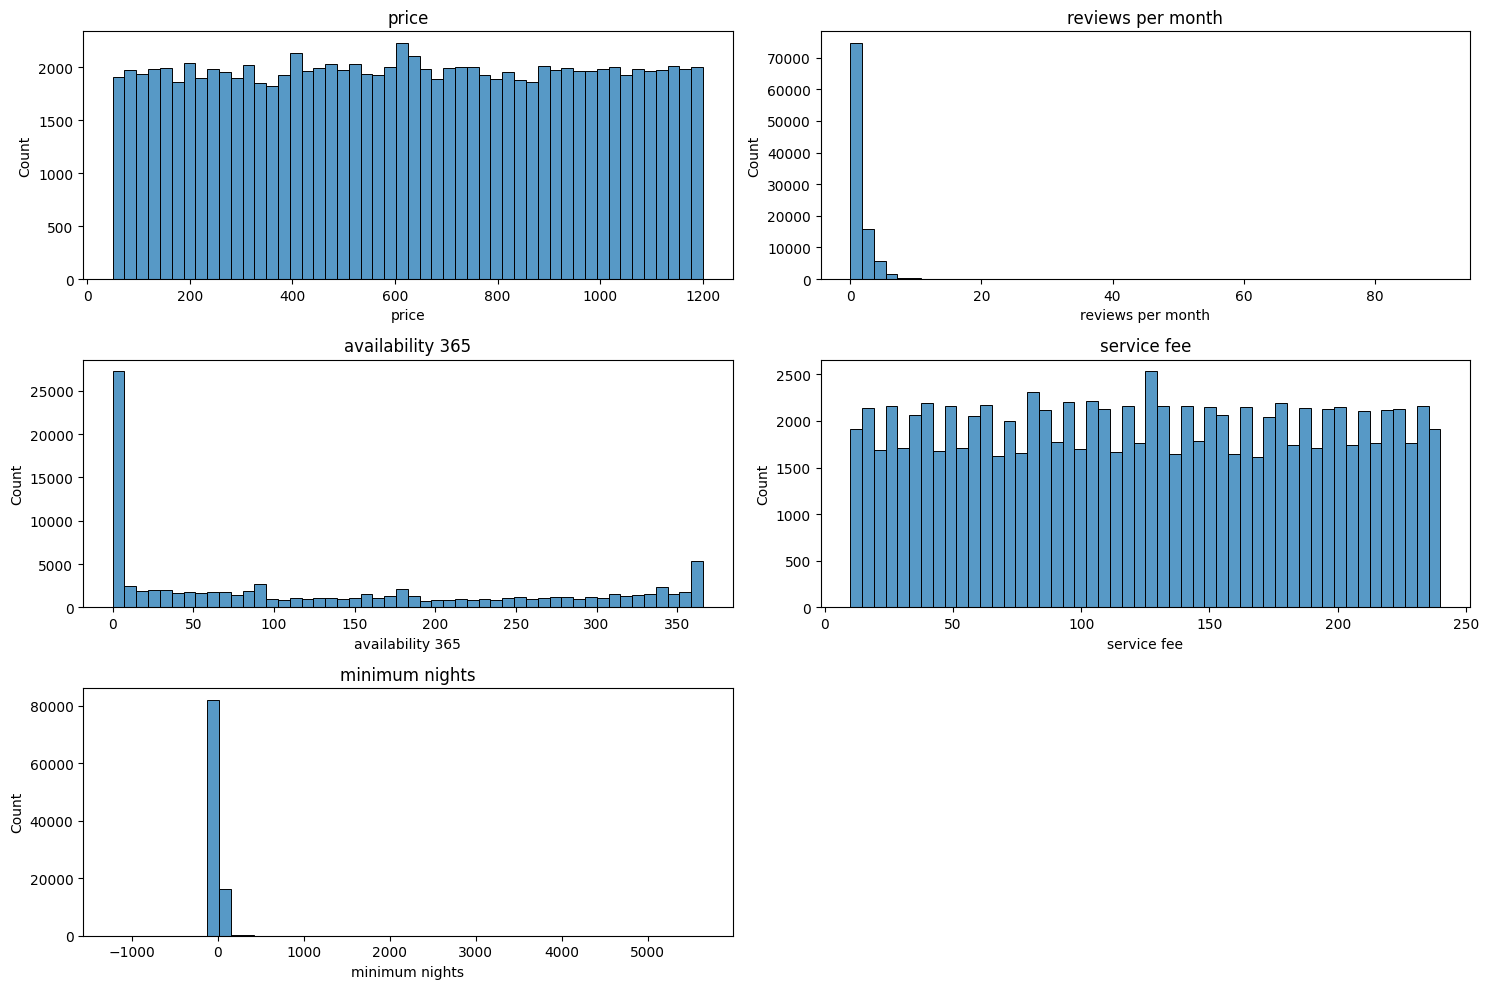

In [6]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_selected[col], bins=50)
    plt.title(col)

plt.tight_layout()
plt.show() 

In [7]:
OUTPUT_DIR = "../artifacts/reports/eda/univariate_analysis/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.savefig(OUTPUT_DIR + "distributions.png")
plt.close()

In [8]:
skewness = {}

for col in cols:
    skewness[col] = float(df_selected[col].skew())

skewness

{'price': -0.000686281436008625,
 'reviews per month': 7.004457522694321,
 'availability 365': 0.493544614186592,
 'service fee': -0.00014643958301003359,
 'minimum nights': 88.90241274757035}

In [9]:
outliers = {}

for col in cols:
    Q1 = df_selected[col].quantile(0.25)
    Q3 = df_selected[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df_selected[
        (df_selected[col] < lower) | (df_selected[col] > upper)
    ].shape[0]

    outliers[col] = {
        "lower_bound": float(lower),
        "upper_bound": float(upper),
        "outlier_count": int(outlier_count)
    }

outliers

{'price': {'lower_bound': -517.0, 'upper_bound': 1771.0, 'outlier_count': 0},
 'reviews per month': {'lower_bound': -2.385,
  'upper_bound': 4.215,
  'outlier_count': 5381},
 'availability 365': {'lower_bound': -376.0,
  'upper_bound': 632.0,
  'outlier_count': 0},
 'service fee': {'lower_bound': -104.5,
  'upper_bound': 355.5,
  'outlier_count': 0},
 'minimum nights': {'lower_bound': -2.5,
  'upper_bound': 9.5,
  'outlier_count': 17843}}

In [10]:
with open(OUTPUT_DIR + "outliers_report.json", "w") as f:
    json.dump(outliers, f, indent=4)

print("Saved:", OUTPUT_DIR + "outliers_report.json")

Saved: ../artifacts/reports/eda/univariate_analysis/outliers_report.json
